In [4]:
%%writefile mysankey.py
# =============================================================================
# mysankey.py — Library Sankey Diagram Custom
# =============================================================================
# Cara pakai:
#   1. Jalankan cell ini PERTAMA untuk menyimpan file mysankey.py ke disk.
#   2. Siapkan data dalam format tabel 3 kolom: [source, target, value]
#      - source : asal aliran (misal: kategori produk, kota asal)
#      - target : tujuan aliran (misal: channel penjualan, kota tujuan)
#      - value  : besarnya aliran (angka, harus numerik)
#   3. Panggil fungsi gambar_sankey() di cell berikutnya.
#
# Lihat cell kedua untuk contoh pemakaian lengkap.
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors


def gambar_sankey(
    df,
    mode_fokus='source',
    judul=None,
    warna_utama='#BA68C8',
    list_warna_custom=None,
    opacity_background=0.1,
    opacity_top=0.95,
    urutan='asli',
    tampilkan_nilai=True,
    format_persen=False,
    bold_sisi='keduanya',
    lebar_node_top=6,
    lebar_node_biasa=3
):
    """
    Membuat Sankey Diagram dengan satu node utama yang disorot.

    Parameters
    ----------
    df : pd.DataFrame
        Tabel data dengan 3 kolom: [source, target, value].
        Kolom pertama = asal, kolom kedua = tujuan, kolom ketiga = nilai.

    mode_fokus : str, default 'source'
        Node mana yang dijadikan fokus highlight.
        - 'source' : sorot node asal dengan nilai terbesar (sisi kiri)
        - 'target' : sorot node tujuan dengan nilai terbesar (sisi kanan)

    judul : str atau None, default None
        Judul diagram.
        - None         : judul otomatis 'Analisis Fokus: <nama node>'
        - ""  (kosong) : tanpa judul
        - "Teks bebas" : judul custom

    warna_utama : str, default '#BA68C8'
        Warna hex untuk aliran dan node yang di-highlight.

    list_warna_custom : list of str atau None, default None
        Daftar warna hex untuk node latar belakang (non-highlight).
        Contoh: ['#8dd3c7', '#ffffb3', '#bebada']
        Jika None, warna dibangkitkan otomatis dari colormap 'turbo'.

    opacity_background : float (0-1), default 0.1
        Tingkat transparansi aliran yang tidak di-highlight.
        Nilai kecil = lebih transparan (memudar ke latar).

    opacity_top : float (0-1), default 0.95
        Tingkat transparansi aliran yang di-highlight.
        Nilai besar = lebih pekat / mencolok.

    urutan : str, default 'asli'
        Urutan tampilan node di diagram.
        - 'asli'       : ikut urutan baris di data
        - 'descending' : node terbesar di atas
        - 'ascending'  : node terkecil di atas

    tampilkan_nilai : bool, default True
        True  = tampilkan angka / persen di samping label node.
        False = hanya tampilkan nama node (diagram lebih bersih).

    format_persen : bool, default False
        True  = nilai ditampilkan sebagai persentase dari total (misal: 34.5%)
        False = nilai ditampilkan sebagai angka mentah (misal: 1200)
        Hanya aktif jika tampilkan_nilai=True.

    bold_sisi : str, default 'keduanya'
        Sisi mana yang label node-nya dicetak tebal untuk node highlight.
        - 'keduanya' : kiri dan kanan sama-sama tebal
        - 'kiri'     : hanya sisi source (kiri) yang tebal
        - 'kanan'    : hanya sisi target (kanan) yang tebal

    lebar_node_top : int atau float, default 6
        Ketebalan batang (node bar) untuk node yang di-highlight.

    lebar_node_biasa : int atau float, default 3
        Ketebalan batang (node bar) untuk node non-highlight.

    Returns
    -------
    None
        Diagram langsung ditampilkan dengan plt.show().
    """

    # ------------------------------------------------------------------
    # 1. PERSIAPAN DATA
    #    Ambil hanya 3 kolom pertama, rename agar konsisten di dalam fungsi.
    # ------------------------------------------------------------------
    df = df.iloc[:, :3].copy()
    df.columns = ['source', 'target', 'value']

    s_total   = df.groupby('source')['value'].sum()   # total nilai per node source
    t_total   = df.groupby('target')['value'].sum()   # total nilai per node target
    grand_total = df['value'].sum()                   # total keseluruhan (untuk %)

    # Tentukan node mana yang dijadikan pusat highlight
    if mode_fokus == 'source':
        top_node = s_total.idxmax()   # source dengan nilai terbesar
    else:
        top_node = t_total.idxmax()   # target dengan nilai terbesar

    # ------------------------------------------------------------------
    # 2. URUTAN TAMPILAN NODE
    # ------------------------------------------------------------------
    if urutan == 'descending':
        sources = sorted(s_total.index.tolist(), key=lambda x: s_total[x], reverse=True)
        targets = sorted(t_total.index.tolist(), key=lambda x: t_total[x], reverse=True)
    elif urutan == 'ascending':
        sources = sorted(s_total.index.tolist(), key=lambda x: s_total[x], reverse=False)
        targets = sorted(t_total.index.tolist(), key=lambda x: t_total[x], reverse=False)
    else:  # 'asli' -- ikut urutan data masuk
        sources = list(pd.unique(df['source']))
        targets = list(pd.unique(df['target']))

    # ------------------------------------------------------------------
    # 3. PALET WARNA
    #    Setiap nama node mendapat warna yang sama di sisi kiri dan kanan
    #    (color map berbasis nama, bukan posisi).
    # ------------------------------------------------------------------
    all_unique_nodes = sorted(list(set(sources + targets)))

    if list_warna_custom is None:
        # Bangkitkan warna otomatis dari colormap turbo, lalu acak urutannya
        cmap = plt.cm.turbo
        generated_colors = cmap(np.linspace(0, 0.75, len(all_unique_nodes)))
        np.random.seed(42)
        np.random.shuffle(generated_colors)
        final_palet = generated_colors
    else:
        final_palet = list_warna_custom

    # Petakan nama node ke warna (wrap-around jika jumlah node > jumlah warna)
    global_color_map = {
        node: final_palet[i % len(final_palet)]
        for i, node in enumerate(all_unique_nodes)
    }

    # ------------------------------------------------------------------
    # 4. LAYOUT KANVAS
    #    Tinggi gambar menyesuaikan jumlah node agar tidak terlalu padat.
    # ------------------------------------------------------------------
    fig_width  = 16
    fig_height = max(10, len(sources) * 0.6, len(targets) * 0.6)
    gap   = df['value'].sum() * 0.02   # jarak antar node (2% dari total)
    max_h = max(
        sum(s_total) + len(sources) * gap,
        sum(t_total) + len(targets) * gap
    )

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')
    ax.set_ylim(max_h * 1.01, -max_h * 0.01)   # sumbu Y terbalik (atas = 0)
    ax.set_xlim(-0.15, 1.15)                    # ruang ekstra untuk label

    def get_y_positions(nodes, totals):
        """Hitung posisi Y awal setiap node (ditumpuk dari atas ke bawah)."""
        y_pos, current = {}, 0
        for node in nodes:
            val = totals.get(node, 0)
            y_pos[node] = current
            current += val + gap
        return y_pos

    y_s = get_y_positions(sources, s_total)
    y_t = get_y_positions(targets, t_total)

    # ------------------------------------------------------------------
    # 5. GAMBAR ALIRAN (RIBBON / PITA)
    #    Aliran ke/dari top_node digambar paling atas (zorder tinggi).
    #    Aliran lain digambar transparan sebagai latar belakang.
    # ------------------------------------------------------------------
    df['is_top'] = (
        (df['source'] == top_node) if mode_fokus == 'source'
        else (df['target'] == top_node)
    )
    df = df.sort_values('is_top')   # gambar non-highlight duluan (tertimpa highlight)

    s_off = {n: 0.0 for n in sources}   # offset akumulatif sisi source
    t_off = {n: 0.0 for n in targets}   # offset akumulatif sisi target
    x = np.linspace(0, 1, 100)          # sumbu X halus untuk kurva sigmoid

    for i, row in df.iterrows():
        s, t, v, is_t = row['source'], row['target'], row['value'], row['is_top']

        # Posisi awal dan akhir pita (vertikal)
        y1 = y_s[s] + s_off[s]
        y2 = y_t[t] + t_off[t]
        s_off[s] += v
        t_off[t] += v

        # Warna dan transparansi: highlight vs latar belakang
        if is_t:
            clr, alp, zorder = warna_utama, opacity_top, 10
        else:
            clr, alp, zorder = global_color_map[s], opacity_background, 1

        # Kurva sigmoid (cosine interpolation) untuk tepi atas dan bawah pita
        y_top = y1 + (y2 - y1) * (1 - np.cos(x * np.pi)) / 2
        y_bot = (y1 + v) + ((y2 + v) - (y1 + v)) * (1 - np.cos(x * np.pi)) / 2
        ax.fill_between(x, y_top, y_bot, color=clr, alpha=alp, zorder=zorder)

    # ------------------------------------------------------------------
    # 6. GAMBAR LABEL DAN NODE BAR
    # ------------------------------------------------------------------
    def draw_labels_exact(nodes, y_starts, totals, x_pos_text, align, is_highlight_side):
        """
        Gambar label teks + garis penunjuk + batang node di satu sisi diagram.

        Parameters
        ----------
        nodes             : daftar nama node yang akan digambar
        y_starts          : dict posisi Y awal tiap node
        totals            : dict total nilai tiap node
        x_pos_text        : posisi X teks label (di luar area diagram)
        align             : 'right' untuk sisi kiri, 'left' untuk sisi kanan
        is_highlight_side : True jika sisi ini adalah sisi yang di-highlight
        """
        labels = []
        for node in nodes:
            total = totals.get(node, 0)
            if total == 0:
                continue

            # Tentukan apakah label node ini perlu dicetak tebal
            is_bold = False
            if is_highlight_side and node == top_node:
                if bold_sisi == 'keduanya':
                    is_bold = True
                elif bold_sisi == 'kiri' and align == 'right':
                    is_bold = True
                elif bold_sisi == 'kanan' and align == 'left':
                    is_bold = True

            labels.append({
                'node'              : node,
                'y_center'          : y_starts[node] + total / 2,
                'is_bold'           : is_bold,
                'y_start'           : y_starts[node],
                'total'             : total,
                'is_actual_top_node': (node == top_node)
            })

        # Anti-tabrakan label: geser ke bawah jika jarak antar label terlalu dekat
        min_d = max_h * 0.012
        y_txt_positions = [l['y_center'] for l in labels]
        for i in range(1, len(y_txt_positions)):
            if y_txt_positions[i] - y_txt_positions[i - 1] < min_d:
                y_txt_positions[i] = y_txt_positions[i - 1] + min_d

        for i, l in enumerate(labels):
            node  = l['node']
            total = l['total']
            is_b  = l['is_bold']

            # Ujung garis penunjuk (dari tepi diagram ke label)
            lx_s    = 0.0 if align == 'right' else 1.0
            gap_txt = 0.01
            lx_e    = x_pos_text + gap_txt if align == 'right' else x_pos_text - gap_txt

            # Susun teks label (nama node + nilai opsional)
            txt_str = f"{node}"
            if tampilkan_nilai:
                if format_persen:
                    pct = (total / grand_total) * 100
                    txt_str += f" ({pct:.1f}%)"
                else:
                    txt_str += f" ({int(total)})"

            # Warna node bar mengikuti warna aliran
            raw_color   = warna_utama if l['is_actual_top_node'] else global_color_map[node]
            b_clr_solid = mcolors.to_rgb(raw_color)

            # Garis penunjuk (tegas untuk highlight, tipis untuk lainnya)
            line_color = warna_utama if is_b else '#CCCCCC'
            ax.plot(
                [lx_s, lx_e], [l['y_center'], y_txt_positions[i]],
                color=line_color,
                lw=1.5 if is_b else 0.8,
                linestyle='--' if is_b else '-'
            )

            # Node bar -- ketebalan berbeda untuk node highlight vs biasa
            current_lw = lebar_node_top if l['is_actual_top_node'] else lebar_node_biasa
            ax.plot(
                [lx_s, lx_s], [l['y_start'], l['y_start'] + total],
                color=b_clr_solid,
                lw=current_lw,
                solid_capstyle='projecting',
                zorder=20
            )

            # Teks label
            ax.text(
                x_pos_text, y_txt_positions[i], txt_str,
                ha=align, va='center',
                fontsize=12 if is_b else 9,
                fontweight='bold' if is_b else 'normal',
                color='black' if is_b else '#444444'
            )

    draw_labels_exact(sources, y_s, s_total, -0.05, 'right', mode_fokus == 'source')
    draw_labels_exact(targets, y_t, t_total,  1.05, 'left',  mode_fokus == 'target')

    # ------------------------------------------------------------------
    # 7. JUDUL
    # ------------------------------------------------------------------
    if judul == "":
        pass   # tidak ada judul
    elif judul is None:
        plt.title(f"Analisis Fokus: {top_node}", fontsize=15, pad=20)
    else:
        plt.title(judul, fontsize=15, pad=20)

    plt.show()


Overwriting mysankey.py



[Contoh 1] Fokus Target | Tampilan Persen | Warna Pastel
-------------------------------------------------------


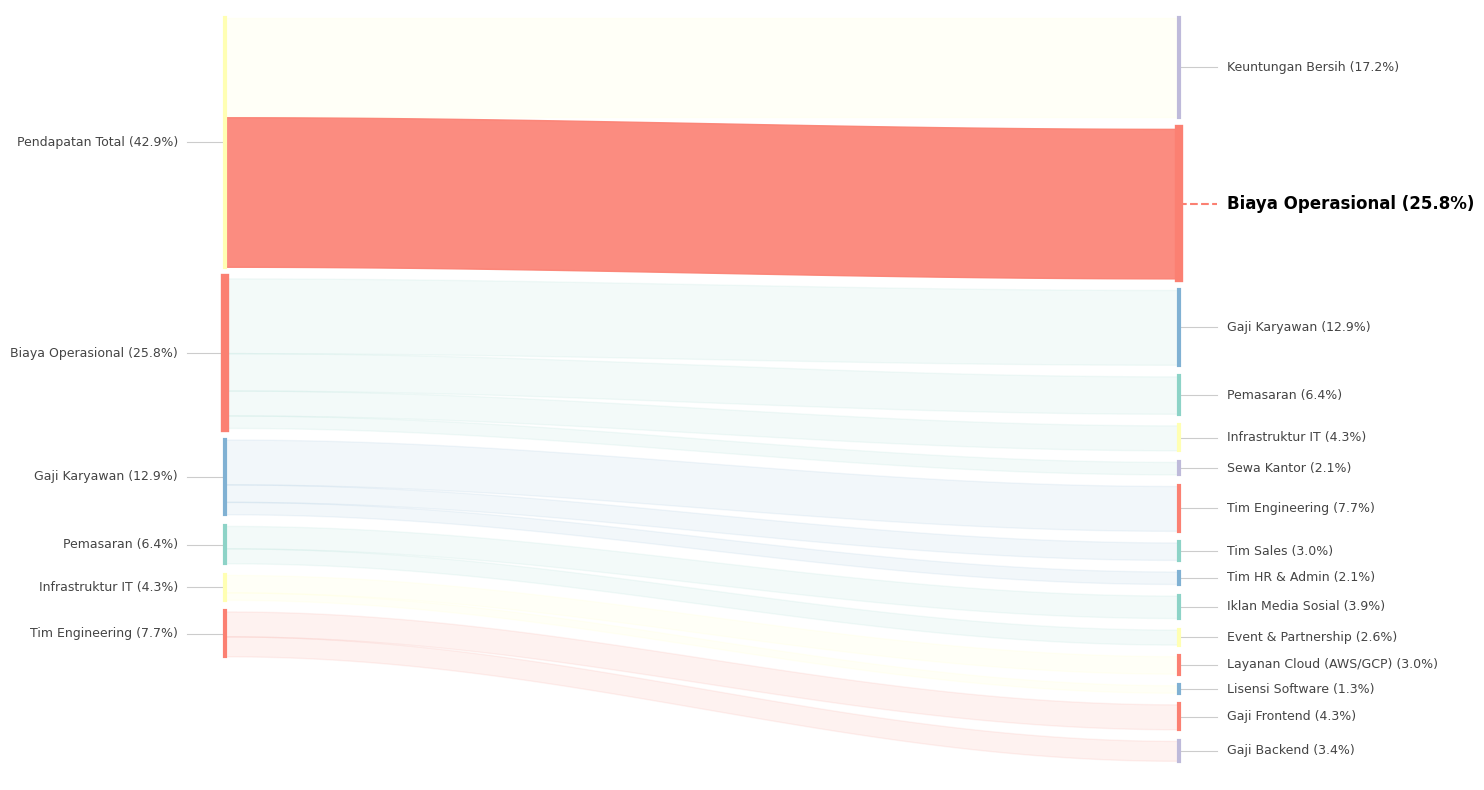


[Contoh 2] Fokus Target | Tanpa Angka | Warna Biru-Ungu
-------------------------------------------------------


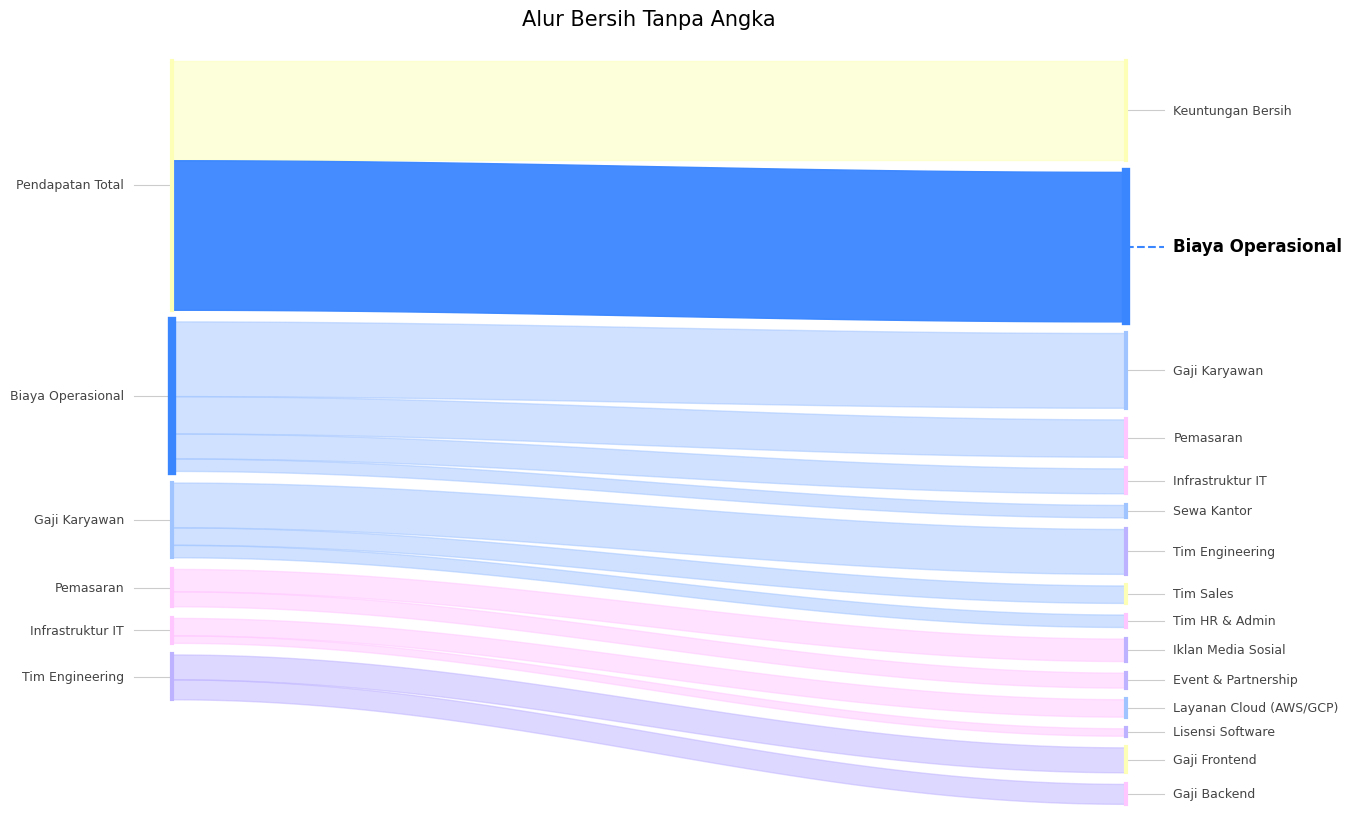


[Contoh 3] Fokus Source | Urutan Descending | Warna Otomatis
------------------------------------------------------------


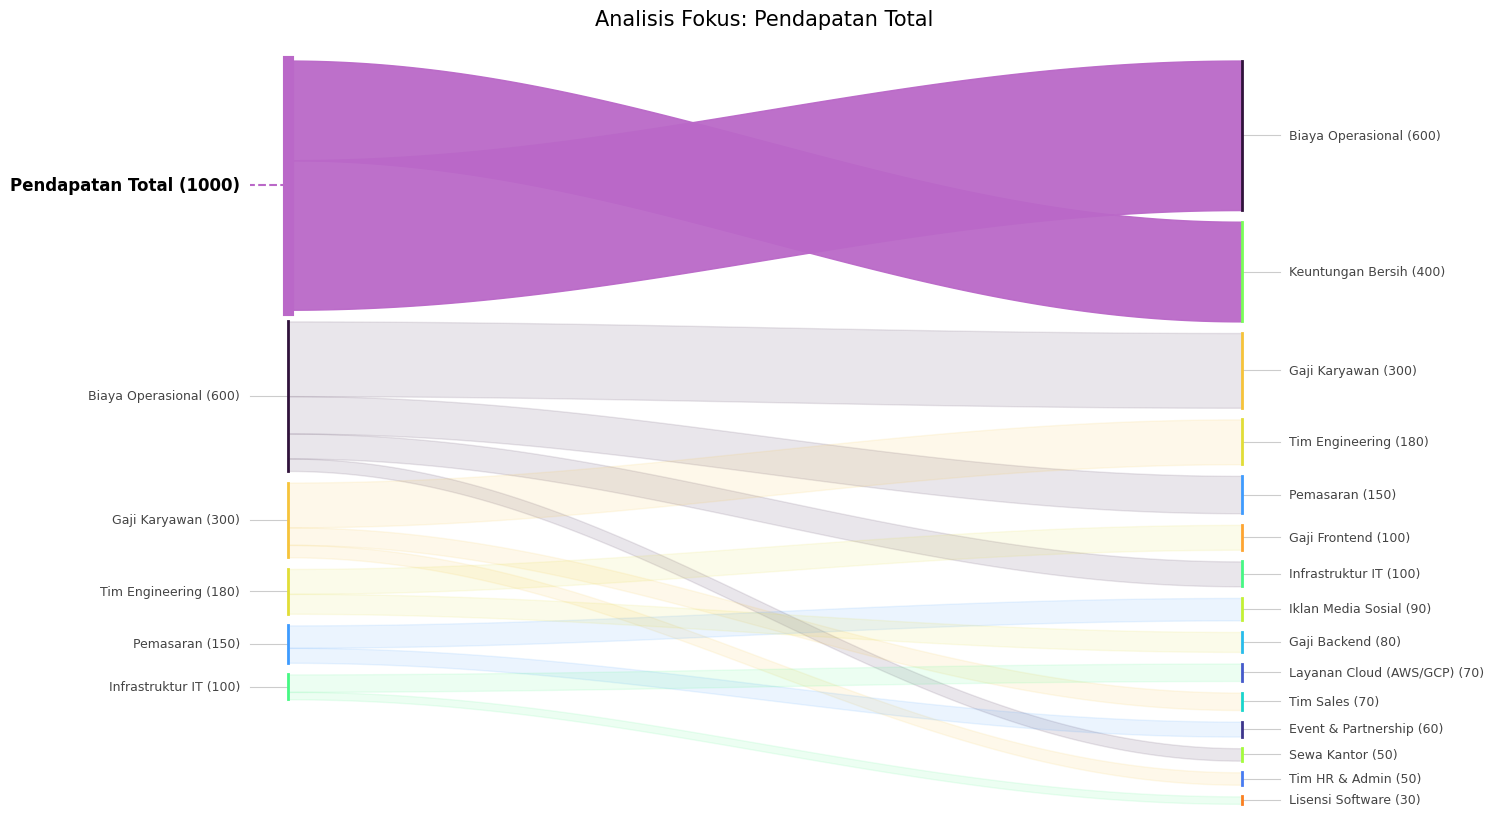

In [5]:
# =============================================================================
# CARA PAKAI -- Sankey Diagram Custom
# =============================================================================
#
# FORMAT DATA YANG DIBUTUHKAN
# ---------------------------
# File Excel (.xlsx) atau CSV dengan 3 kolom (nama kolom bebas):
#
#   Kolom 1 (source) : Asal aliran
#                      Contoh: nama produk, kota asal, divisi, channel masuk
#   Kolom 2 (target) : Tujuan aliran
#                      Contoh: nama channel, kota tujuan, kategori, outlet
#   Kolom 3 (value)  : Besarnya aliran (angka / numerik)
#                      Contoh: jumlah unit, nilai penjualan, jumlah transaksi
#
#   Contoh isi tabel:
#   +--------------+--------------+--------+
#   | Produk       | Channel      | Sales  |
#   +--------------+--------------+--------+
#   | Laptop       | Online       |  1200  |
#   | Laptop       | Toko Fisik   |   800  |
#   | Handphone    | Online       |  2100  |
#   | Handphone    | Reseller     |   950  |
#   | Tablet       | Toko Fisik   |   430  |
#   +--------------+--------------+--------+
#
# CARA MENJALANKAN
# ----------------
#   1. Jalankan Cell 1 (%%writefile) terlebih dahulu untuk membuat mysankey.py
#   2. Jalankan cell ini, lalu upload file data saat diminta
#   3. Sesuaikan parameter di bawah sesuai kebutuhan
#
# REFERENSI PARAMETER UTAMA
# -------------------------
#   mode_fokus        : 'source' atau 'target'
#                       node mana yang di-highlight (otomatis pilih yang terbesar)
#   judul             : None (judul otomatis), "" (tanpa judul), atau "Judul Custom"
#   warna_utama       : warna hex untuk aliran yang di-highlight, misal '#3A86FF'
#   list_warna_custom : list warna hex untuk node lainnya (opsional)
#   opacity_background: 0.0-1.0, transparansi aliran non-highlight (kecil = lebih pudar)
#   opacity_top       : 0.0-1.0, ketebalan warna aliran yang di-highlight
#   urutan            : 'asli', 'descending', atau 'ascending'
#   tampilkan_nilai   : True (tampilkan angka) / False (hanya nama)
#   format_persen     : True (tampilkan %) / False (tampilkan angka mentah)
#   bold_sisi         : 'keduanya', 'kiri', atau 'kanan'
#   lebar_node_top    : ketebalan batang node highlight (default 6)
#   lebar_node_biasa  : ketebalan batang node biasa (default 3)
# =============================================================================

import mysankey
import importlib
import pandas as pd
import io
from google.colab import files

# Reload otomatis setiap kali cell ini dijalankan
# (berguna saat kamu baru saja mengedit mysankey.py)
importlib.reload(mysankey)

# ------------------------------------------------------------------
# UPLOAD DATA
# Jika df_input sudah ada dari run sebelumnya, tidak perlu upload ulang.
# Restart runtime jika ingin ganti file data.
# ------------------------------------------------------------------
if 'df_input' not in locals():
    print("Silakan upload file Excel (.xlsx) atau CSV (.csv) kamu:")
    uploaded = files.upload()
    filename = next(iter(uploaded))
    if filename.endswith('.csv'):
        df_input = pd.read_csv(io.BytesIO(uploaded[filename]))
    else:
        df_input = pd.read_excel(io.BytesIO(uploaded[filename]))
    print(f"\nData berhasil dimuat: {df_input.shape[0]} baris, {df_input.shape[1]} kolom")
    print(df_input.head())

# ==================================================================
# CONTOH 1: Fokus ke sisi TARGET dengan tampilan persen
# ==================================================================
print("\n[Contoh 1] Fokus Target | Tampilan Persen | Warna Pastel")
print("-" * 55)

warna_pastel = ['#8dd3c7', '#ffffb3', '#bebada', '#fb8072', '#80b1d3']

mysankey.gambar_sankey(
    df_input,

    mode_fokus='target',          # sorot node target terbesar (sisi kanan)
    judul="",                     # tanpa judul
    urutan='asli',                # urutan node sesuai urutan di file asli

    tampilkan_nilai=True,         # tampilkan nilai di samping label
    format_persen=True,           # format sebagai persentase

    bold_sisi='kanan',            # hanya sisi kanan yang tebal

    warna_utama='#fb8072',        # warna highlight: merah pastel
    list_warna_custom=warna_pastel,
    opacity_top=0.9,
    opacity_background=0.1,
)

# ==================================================================
# CONTOH 2: Tampilan bersih tanpa angka, warna biru-ungu
# ==================================================================
print("\n[Contoh 2] Fokus Target | Tanpa Angka | Warna Biru-Ungu")
print("-" * 55)

mysankey.gambar_sankey(
    df_input,

    mode_fokus='target',          # sorot node target terbesar
    judul="Alur Bersih Tanpa Angka",

    tampilkan_nilai=False,        # sembunyikan angka -- diagram lebih bersih

    bold_sisi='kanan',            # hanya sisi kanan yang tebal

    list_warna_custom=['#A0C4FF', '#BDB2FF', '#FFC6FF', '#FDFFB6'],
    warna_utama='#3A86FF',        # warna highlight: biru cerah
    opacity_background=0.5,       # latar belakang sedikit lebih pekat
)

# ==================================================================
# CONTOH 3: Fokus ke sisi SOURCE, urutan descending
# ==================================================================
print("\n[Contoh 3] Fokus Source | Urutan Descending | Warna Otomatis")
print("-" * 60)

mysankey.gambar_sankey(
    df_input,

    mode_fokus='source',          # sorot node source terbesar (sisi kiri)
    judul=None,                   # judul otomatis: "Analisis Fokus: <nama node>"
    urutan='descending',          # urutkan dari nilai terbesar di atas

    tampilkan_nilai=True,
    format_persen=False,          # tampilkan angka mentah

    bold_sisi='keduanya',
    warna_utama='#BA68C8',        # ungu
    lebar_node_top=8,             # node highlight lebih tebal dari default
    lebar_node_biasa=2,
)
